In [1]:
%load_ext autoreload
from tqdm import tqdm
import torch
import torchvision
import matplotlib.pyplot as plt

from models.CLIP import CLIP

device = "cuda" if torch.cuda.is_available() else "cpu"
clip_model = CLIP("ViT-B/32", device)

/home/chris/ImageClassificationAssignment/venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Files already downloaded and verified
Files already downloaded and verified


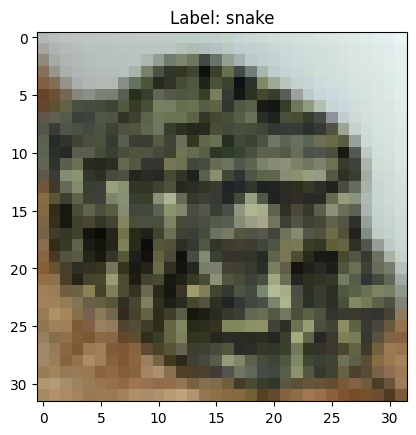

In [2]:
cifar100 = torchvision.datasets.CIFAR100(root='./data', download=True, train=False, transform=clip_model.preprocess)
cifar100_visualize = torchvision.datasets.CIFAR100(root='./data', download=True, train=False)

clip_model.compute_text_features(cifar100.classes)

idx = 3637
X, y = cifar100[idx]
image, _ = cifar100_visualize[idx]
with torch.no_grad():
    output = clip_model(X.unsqueeze(0))
    label = cifar100.classes[output.argmax(axis=1)]
plt.imshow(image)
plt.title(f"Label: {label}")
plt.show()

In [3]:
from torch.utils.data import DataLoader

batch_size = 64
dataloader = DataLoader(cifar100, batch_size=batch_size, shuffle=True)
score = 0
clip_model.model.eval()

with torch.no_grad():
    for X, y in tqdm(dataloader):
        pred = clip_model(X).argmax(axis=1)
        score = score + (pred == y).sum()

t1_accuracy = score / len(cifar100)
print(f"Top-1 accuracy: {t1_accuracy*100:.2f}%")

In [4]:
import torchvision.transforms as transforms

from models.MEMO import MEMO

augmentations = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(degrees=30),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.2),
    transforms.RandomResizedCrop(size=224, scale=(0.08, 1.0), ratio=(0.75, 1.333)),
])

# Give SGD (lr=0.005 + 64 num augmentations) loss to MEMO --> needed for update
memo = MEMO(clip_model, augmentations, device, 20)
with torch.no_grad():
    for X, y in dataloader:
        Xs = X[:1]
        print(memo(Xs))
        break

torch.Size([21, 100])


RuntimeError: element 0 of tensors does not require grad and does not have a grad_fn